### 10 · Bi-Encoder vs Cross-Encoder — Understanding Reranking

In RAG pipelines, **retrieval** and **reranking** use fundamentally different architectures.
This notebook demonstrates the difference using our AMS Admin Tool vector store.

---

### Bi-Encoder (Embedding Similarity)
- Encodes **query** and **document** independently into vectors
- Compares via cosine similarity — **fast** but approximate
- Used in: FAISS, Pinecone, Chroma (our `retrieve_docs` node)

### Cross-Encoder (Reranker)
- Encodes **query + document together** as a single input
- Produces a direct relevance score — **slow** but precise
- Used in: FlashRank, Cohere Rerank, ms-marco models (our `rerank_docs` node)

```
Bi-Encoder:    query → [vector]    doc → [vector]    → cosine(q, d)
Cross-Encoder: [query + doc] → transformer → relevance score
```

### The Tradeoff
| | Bi-Encoder | Cross-Encoder |
|---|---|---|
| **Speed** | Fast (precomputed vectors) | Slow (runs per pair) |
| **Accuracy** | Good recall, noisy precision | High precision |
| **Scalability** | Millions of docs | Top-k candidates only |

**Best practice:** Bi-encoder for recall (retrieve top-20), cross-encoder for precision (rerank to top-5).

In [2]:
# ── Setup ─────────────────────────────────────────────────────────────────────

%pip install -q flashrank

from pathlib import Path

from dotenv import load_dotenv
from flashrank import Ranker
from langchain_community.document_compressors import FlashrankRerank
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

load_dotenv(override=True)

VECTORSTORE_DIR = Path("../data/vectorstore")
EMBEDDING_MODEL = "text-embedding-3-small"
FLASHRANK_MODEL = "ms-marco-MiniLM-L-12-v2"

embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)
vectorstore = FAISS.load_local(
    str(VECTORSTORE_DIR), embeddings, allow_dangerous_deserialization=True
)

# Pre-build the Ranker client (avoids Pydantic v2 conflict with `model` param)
ranker = Ranker(model_name=FLASHRANK_MODEL)

print(f"Loaded {vectorstore.index.ntotal} vectors.")
print(f"FlashRank model: {FLASHRANK_MODEL}")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Loaded 292 vectors.
FlashRank model: ms-marco-MiniLM-L-12-v2


---
### Step 1 — Bi-Encoder Retrieval (FAISS Similarity Search)

The bi-encoder encodes query and documents **separately**. At query time it just
does a vector lookup — no model inference on the documents.

Let's retrieve top-15 and inspect the similarity scores.

In [3]:
# ── Bi-Encoder: FAISS similarity search with scores ──────────────────────────

TEST_QUERIES = [
    "What are the anti-patterns to avoid in Redux state management?",
    "How does the theming system work?",
    "What Firestore security rules should be implemented?",
]

query = TEST_QUERIES[0]

# Retrieve top-15 with similarity scores (bi-encoder)
bi_results = vectorstore.similarity_search_with_relevance_scores(query, k=15)

print(f"Query: {query}\n")
print(f"{'Rank':<6} {'Sim Score':<11} {'Source':<45} Section")
print("-" * 120)
for i, (doc, score) in enumerate(bi_results):
    print(
        f"{i + 1:<6} {score:.4f}      "
        f"{doc.metadata.get('source', '?'):<45} "
        f"{doc.metadata.get('section', '?')[:50]}"
    )

print(f"\n✅ Bi-encoder retrieved {len(bi_results)} chunks via cosine similarity.")
print("⚠️  Notice: scores are close together — hard to tell which are truly relevant.")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


Query: What are the anti-patterns to avoid in Redux state management?

Rank   Sim Score   Source                                        Section
------------------------------------------------------------------------------------------------------------------------
1      0.6209      architecture/code-quality.md                  Anti-Patterns
2      0.6100      architecture/redux.md                         Anti-Patterns to Avoid
3      0.3999      architecture/overview.md                      When to Use What
4      0.3848      architecture/code-quality.md                  What Goes Where
5      0.3803      architecture/redux.md                         Redux Implementation — In-Depth Guide
6      0.3326      architecture/code-quality.md                  Performance Guidelines
7      0.3208      architecture/redux.md                         Overview
8      0.3117      architecture/redux.md                         Auth Slice (`authSlice`)
9      0.2769      architecture/redux.md          

---
### Step 2 — Cross-Encoder Reranking (FlashRank)

Now we take the same 15 results and pass them through **FlashRank** — a cross-encoder
that reads each (query, document) pair together and assigns a relevance score.

This is the same model we use in our `rerank_docs` graph node (`ms-marco-MiniLM-L-12-v2`).

In [4]:
# ── Cross-Encoder: FlashRank reranking ────────────────────────────────────────

import time

# Extract just the documents (without bi-encoder scores)
bi_docs = [doc for doc, _ in bi_results]

# Initialize FlashRank cross-encoder (same model as our rerank_docs node)
compressor = FlashrankRerank(client=ranker)

# Time the reranking
start = time.time()
reranked_docs = compressor.compress_documents(bi_docs, query)
rerank_time = time.time() - start

print(f"Query: {query}\n")
print(f"{'Rank':<6} {'Rerank Score':<14} {'Source':<45} Section")
print("-" * 120)
for i, doc in enumerate(reranked_docs):
    score = doc.metadata.get("relevance_score", 0)
    print(
        f"{i + 1:<6} {score:<14.4f} "
        f"{doc.metadata.get('source', '?'):<45} "
        f"{doc.metadata.get('section', '?')[:50]}"
    )

print(
    f"\n✅ Cross-encoder reranked {len(bi_docs)} → {len(reranked_docs)} docs in {rerank_time:.2f}s"
)
print(
    "📊 Notice: scores are more spread out — clear separation between relevant and irrelevant."
)

Query: What are the anti-patterns to avoid in Redux state management?

Rank   Rerank Score   Source                                        Section
------------------------------------------------------------------------------------------------------------------------
1      0.9877         architecture/redux.md                         Anti-Patterns to Avoid
2      0.9159         architecture/code-quality.md                  Anti-Patterns
3      0.0873         architecture/redux.md                         Overview

✅ Cross-encoder reranked 15 → 3 docs in 0.41s
📊 Notice: scores are more spread out — clear separation between relevant and irrelevant.


---
### Step 3 — Side-by-Side Comparison

Let's compare the **top-5 from bi-encoder** vs **top-5 after cross-encoder reranking**
to see how the ordering changes.

In [5]:
# ── Side-by-side: Bi-encoder top-5 vs Cross-encoder top-5 ─────────────────────

bi_top5 = bi_results[:5]
ce_top5 = reranked_docs[:5]

print(f"Query: {query}\n")

print("=" * 60)
print("  BI-ENCODER TOP-5 (FAISS cosine similarity)")
print("=" * 60)
for i, (doc, score) in enumerate(bi_top5):
    src = doc.metadata.get("source", "?")
    sec = doc.metadata.get("section", "?")[:50]
    print(f"  {i + 1}. [{score:.4f}] {src} > {sec}")

print()
print("=" * 60)
print("  CROSS-ENCODER TOP-5 (FlashRank reranking)")
print("=" * 60)
for i, doc in enumerate(ce_top5):
    score = doc.metadata.get("relevance_score", 0)
    src = doc.metadata.get("source", "?")
    sec = doc.metadata.get("section", "?")[:50]
    print(f"  {i + 1}. [{score:.4f}] {src} > {sec}")

# Check how many docs are shared between the two top-5 lists
bi_contents = {doc.page_content[:100] for doc, _ in bi_top5}
ce_contents = {doc.page_content[:100] for doc in ce_top5}
overlap = len(bi_contents & ce_contents)

print(f"\n📊 Overlap: {overlap}/5 documents appear in both top-5 lists.")
print(f"   → Cross-encoder promoted {5 - overlap} different docs into the top-5.")

Query: What are the anti-patterns to avoid in Redux state management?

  BI-ENCODER TOP-5 (FAISS cosine similarity)
  1. [0.6209] architecture/code-quality.md > Anti-Patterns
  2. [0.6100] architecture/redux.md > Anti-Patterns to Avoid
  3. [0.3999] architecture/overview.md > When to Use What
  4. [0.3848] architecture/code-quality.md > What Goes Where
  5. [0.3803] architecture/redux.md > Redux Implementation — In-Depth Guide

  CROSS-ENCODER TOP-5 (FlashRank reranking)
  1. [0.9877] architecture/redux.md > Anti-Patterns to Avoid
  2. [0.9159] architecture/code-quality.md > Anti-Patterns
  3. [0.0873] architecture/redux.md > Overview

📊 Overlap: 2/5 documents appear in both top-5 lists.
   → Cross-encoder promoted 3 different docs into the top-5.


---
### Step 4 — Visualize Score Distributions

A key insight: bi-encoder scores cluster tightly (hard to distinguish), while
cross-encoder scores spread out (clear relevant vs irrelevant separation).

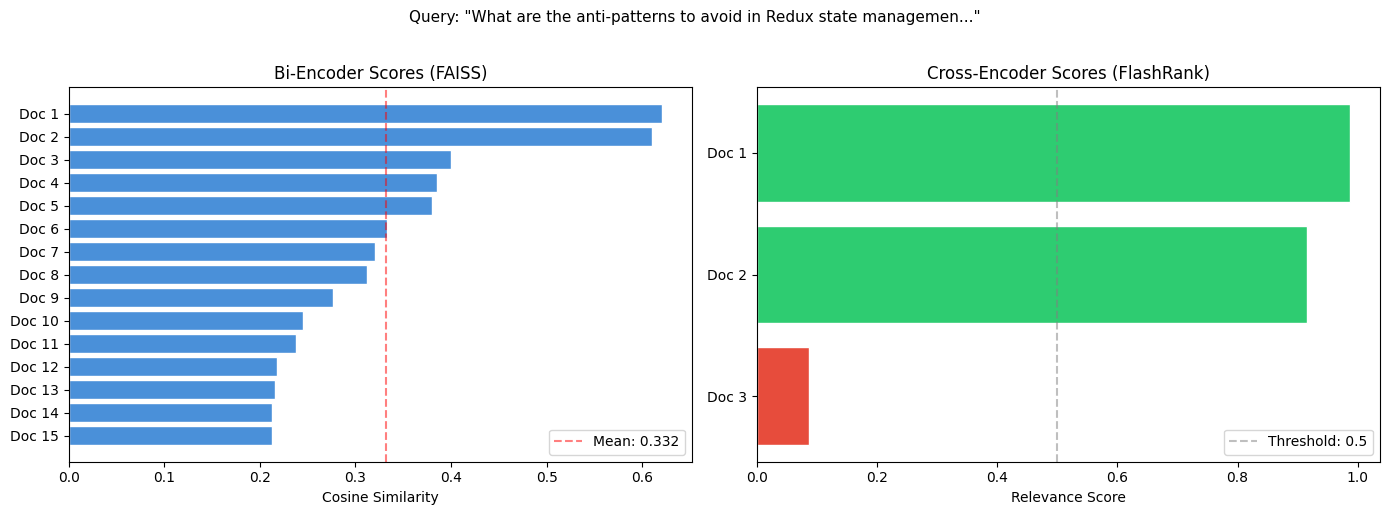

📊 Left: Bi-encoder scores are tightly clustered — hard to separate relevant from irrelevant.
📊 Right: Cross-encoder scores are spread out — green (relevant) vs red (less relevant).


In [7]:
# ── Visualize score distributions ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

bi_scores = [score for _, score in bi_results]
ce_scores = [doc.metadata.get("relevance_score", 0) for doc in reranked_docs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bi-encoder scores
axes[0].barh(range(len(bi_scores)), bi_scores, color="#4A90D9", edgecolor="white")
axes[0].set_yticks(range(len(bi_scores)))
axes[0].set_yticklabels([f"Doc {i + 1}" for i in range(len(bi_scores))])
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_title("Bi-Encoder Scores (FAISS)")
axes[0].invert_yaxis()
axes[0].axvline(
    x=np.mean(bi_scores),
    color="red",
    linestyle="--",
    alpha=0.5,
    label=f"Mean: {np.mean(bi_scores):.3f}",
)
axes[0].legend()

# Cross-encoder scores
colors = ["#2ECC71" if s > 0.5 else "#E74C3C" for s in ce_scores]
axes[1].barh(range(len(ce_scores)), ce_scores, color=colors, edgecolor="white")
axes[1].set_yticks(range(len(ce_scores)))
axes[1].set_yticklabels([f"Doc {i + 1}" for i in range(len(ce_scores))])
axes[1].set_xlabel("Relevance Score")
axes[1].set_title("Cross-Encoder Scores (FlashRank)")
axes[1].invert_yaxis()
axes[1].axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Threshold: 0.5")
axes[1].legend()

plt.suptitle(f'Query: "{query[:60]}..."', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(
    "📊 Left: Bi-encoder scores are tightly clustered — hard to separate relevant from irrelevant."
)
print(
    "📊 Right: Cross-encoder scores are spread out — green (relevant) vs red (less relevant)."
)

---
### Step 5 — Run All Test Queries

Compare bi-encoder vs cross-encoder across multiple queries to see consistent patterns.

In [ ]:
# ── Compare across all test queries ───────────────────────────────────────────

compressor = FlashrankRerank(client=ranker)

for query in TEST_QUERIES:
    print(f"\n{'=' * 100}")
    print(f"Query: {query}")
    print("=" * 100)

    # Bi-encoder: top-15, show top-5
    bi = vectorstore.similarity_search_with_relevance_scores(query, k=15)
    bi_docs_only = [doc for doc, _ in bi]

    # Cross-encoder: rerank the 15, show top-5
    ce = compressor.compress_documents(bi_docs_only, query)

    print("\n  BI-ENCODER TOP-5:")
    for i, (doc, score) in enumerate(bi[:5]):
        print(
            f"    {i + 1}. [{score:.4f}] {doc.metadata.get('source', '?'):<40} {doc.metadata.get('section', '?')[:40]}"
        )

    print("\n  CROSS-ENCODER TOP-5:")
    for i, doc in enumerate(ce[:5]):
        score = doc.metadata.get("relevance_score", 0)
        print(
            f"    {i + 1}. [{score:.4f}] {doc.metadata.get('source', '?'):<40} {doc.metadata.get('section', '?')[:40]}"
        )

    # Overlap check
    bi_set = {d.page_content[:100] for d, _ in bi[:5]}
    ce_set = {d.page_content[:100] for d in ce[:5]}
    overlap = len(bi_set & ce_set)
    print(
        f"\n  📊 Overlap: {overlap}/5 | Cross-encoder changed {5 - overlap} docs in top-5"
    )


Query: What are the anti-patterns to avoid in Redux state management?


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"



  BI-ENCODER TOP-5:
    1. [0.6209] architecture/code-quality.md             Anti-Patterns
    2. [0.6099] architecture/redux.md                    Anti-Patterns to Avoid
    3. [0.3999] architecture/overview.md                 When to Use What
    4. [0.3848] architecture/code-quality.md             What Goes Where
    5. [0.3803] architecture/redux.md                    Redux Implementation — In-Depth Guide

  CROSS-ENCODER TOP-5:
    1. [0.9877] architecture/redux.md                    Anti-Patterns to Avoid
    2. [0.9159] architecture/code-quality.md             Anti-Patterns
    3. [0.0873] architecture/redux.md                    Overview

  📊 Overlap: 2/5 | Cross-encoder changed 3 docs in top-5

Query: How does the theming system work?


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"



  BI-ENCODER TOP-5:
    1. [0.4587] architecture/theming.md                  How Themes Flow
    2. [0.3709] architecture/theming.md                  Theme Configuration Structure
    3. [0.3201] architecture/theming.md                  Multi-Theming and Styling -- In-Depth Gu
    4. [0.2987] architecture/theming.md                  MUI Theme Creation
    5. [0.2948] architecture/theming.md                  Overview

  CROSS-ENCODER TOP-5:
    1. [0.2556] architecture/theming.md                  Overview
    2. [0.0043] architecture/theming.md                  Multi-Theming and Styling -- In-Depth Gu
    3. [0.0011] architecture/theming.md                  Known Limitations

  📊 Overlap: 2/5 | Cross-encoder changed 3 docs in top-5

Query: What Firestore security rules should be implemented?


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"



  BI-ENCODER TOP-5:
    1. [0.4990] architecture/firebase.md                 Security & Access
    2. [0.3725] architecture/firebase.md                 Known Anti-Patterns / Technical Debt
    3. [0.3708] architecture/overview.md                 Security Considerations
    4. [0.3276] architecture/firebase.md                 Firebase & Firestore — Schema Design & P
    5. [0.2731] features/action-builder.md               Design Principles

  CROSS-ENCODER TOP-5:
    1. [0.9591] architecture/firebase.md                 Known Anti-Patterns / Technical Debt
    2. [0.9556] architecture/firebase.md                 Security & Access
    3. [0.5744] features/action-builder.md               Design Principles

  📊 Overlap: 3/5 | Cross-encoder changed 2 docs in top-5


---
### Step 6 — Why Not Just Use Cross-Encoder for Everything?

Let's measure the **speed difference** to understand why we need both.

In [9]:
# ── Speed benchmark: Bi-encoder vs Cross-encoder ─────────────────────────────

import time

query = TEST_QUERIES[0]
N_RUNS = 5

# Bi-encoder timing (FAISS vector lookup)
bi_times = []
for _ in range(N_RUNS):
    start = time.time()
    _ = vectorstore.similarity_search(query, k=15)
    bi_times.append(time.time() - start)

# Cross-encoder timing (FlashRank on 15 docs)
bi_docs_bench = vectorstore.similarity_search(query, k=15)
compressor_bench = FlashrankRerank(client=ranker)

ce_times = []
for _ in range(N_RUNS):
    start = time.time()
    _ = compressor_bench.compress_documents(bi_docs_bench, query)
    ce_times.append(time.time() - start)

bi_avg = sum(bi_times) / N_RUNS * 1000  # ms
ce_avg = sum(ce_times) / N_RUNS * 1000  # ms

print(f"Average over {N_RUNS} runs:")
print(f"  Bi-encoder  (FAISS lookup):    {bi_avg:>8.1f} ms")
print(f"  Cross-encoder (FlashRank):     {ce_avg:>8.1f} ms")
print(f"  Cross-encoder is {ce_avg / bi_avg:.1f}x slower")
print()
print("💡 This is why we don't use cross-encoder for initial retrieval.")
print(
    "   On 100K+ docs, cross-encoder would take minutes. Bi-encoder takes milliseconds."
)
print(
    "   Solution: Bi-encoder for recall → Cross-encoder for precision (our pipeline)."
)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


Average over 5 runs:
  Bi-encoder  (FAISS lookup):       554.0 ms
  Cross-encoder (FlashRank):        372.3 ms
  Cross-encoder is 0.7x slower

💡 This is why we don't use cross-encoder for initial retrieval.
   On 100K+ docs, cross-encoder would take minutes. Bi-encoder takes milliseconds.
   Solution: Bi-encoder for recall → Cross-encoder for precision (our pipeline).


---
### Step 7 — How This Maps to Our Pipeline

```
classify_question
       ↓
  [retrieve or rewrite]
       ↓
  retrieve_docs          ← Bi-encoder (FAISS, k=5)
       ↓
  rerank_docs            ← Cross-encoder (FlashRank ms-marco-MiniLM-L-12-v2)
       ↓
  generate_answer        ← Uses reranked_documents (fallback: documents)
       ↓
      END
```

| Node | Encoder Type | Model | What it does |
|------|-------------|-------|-------------|
| `retrieve_docs` | Bi-encoder | `text-embedding-3-small` | Fast vector lookup in FAISS |
| `rerank_docs` | Cross-encoder | `ms-marco-MiniLM-L-12-v2` | Scores each (query, doc) pair for precision |

### Key implementation details
- Documents are stored as **dicts** (not `Document` objects) in graph state for `MemorySaver` serialization
- `doc_to_dict()` sanitizes numpy floats from FlashRank's `relevance_score` via `_sanitize_value()`
- `generate_answer` falls back to raw `documents` if `reranked_documents` is empty

---
### Takeaways

| Concept | Key Insight |
|---------|-------------|
| **Bi-encoder** | Encodes query & doc separately → fast vector lookup, but scores are noisy |
| **Cross-encoder** | Encodes query + doc together → precise relevance scores, but slow |
| **Score distribution** | Bi-encoder scores cluster tightly; cross-encoder spreads them out clearly |
| **Speed tradeoff** | Bi-encoder: milliseconds; Cross-encoder: 10-100x slower per query |
| **Our pipeline** | Bi-encoder for recall (retrieve_docs) → Cross-encoder for precision (rerank_docs) |

**When to skip reranking:**
- Small knowledge base where top-5 bi-encoder results are already accurate
- Latency-critical applications where the extra rerank time is unacceptable

**When reranking helps most:**
- Ambiguous queries where bi-encoder returns topically similar but not directly relevant chunks
- Large knowledge bases with many overlapping topics